# RavenStack – Updating Reactive Customer Success Operations


## 1. Introduction & usage guidelines

Markdown and inline comments guide technical stakeholders through executing code. A complete summary outcomes is provided in the accompanying case study.

Execute the code in all cells in the order they appear below.

## 2. Workstation preparation

### 2.1 Error handling

In [1]:
# Execute to supress memory leak warning using K-Means
import os
os.environ['OMP_NUM_THREADS'] = '8'

In [2]:
# Suppress warnings to maintain clean outputs
# Comment out as a first step to debug any problems encountered executing code in this notebook
import warnings
warnings.filterwarnings('ignore')

### 2.2 Libraries and packages

In [3]:
# Ensure nltk is available in the environment
!pip install nltk

In [4]:
# Data wrangling and numeric operations
import pandas as pd
import numpy as np

# Date manipulation
import datetime as dt

# Visualisation and plot styling
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Regex for text cleaning
import re

# Machine learning and modeling
import sklearn
from imblearn.over_sampling import SMOTE  
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import silhouette_score
from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import MinMaxScaler


# Statistical analysis
import scipy as scp
import scipy.stats as stats

# Natural Language Processing
import nltk
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from textblob import TextBlob
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
from collections import Counter

### 2.3 Data ingestion

In [5]:
# Import accounts data
raccs = pd.read_csv('ravenstack_accounts.csv')

# Import subscription data
subs = pd.read_csv('ravenstack_subscriptions.csv')

# Import support ticket data
stix = pd.read_csv('ravenstack_support_tickets.csv')

# Import churn event data
chur = pd.read_csv('ravenstack_churn_events.csv')

# Import usage data
fuse = pd.read_csv('ravenstack_feature_usage.csv')

### 2.4 Functions

In [6]:
# Function used in EDA to matchChurn Event reason codes to feedback text
def feedback_matches_reason(feedback_text, reason_code):
    if pd.isna(feedback_text):
        return None
    if reason_code == 'unknown':
        return None  # Exclude from mismatch analysis
    
    feedback_lower = feedback_text.lower()
    keywords = reason_keywords.get(reason_code, [])
    
    return any(keyword in feedback_lower for keyword in keywords)

In [7]:
# Visualisations - countplots
def export_countplot(df, column, filename, title, xlabel, ylabel, figsize=(10, 6), rotation=45):
    # Set up canvas before plotting
    fig, ax = plt.subplots(figsize=figsize)

    # Plot directly onto the axes
    sns.countplot(data=df, x=column, order=df[column].value_counts().index, ax=ax)

    # Format chart
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(axis='x', labelrotation=90)
    plt.tight_layout()

    # Export to file in home directory and display
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

In [8]:
# Visualisations - NLP histograms
def export_sentiment_hist(df, column, filename, title, xlabel, ylabel='Frequency', figsize=(10, 6)):
    
    # Format chart
    plt.figure(figsize=figsize)
    plt.hist(df[column])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(axis='y', alpha=0.75)
    
    # Export to file in home directory and display
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

In [9]:
# Visualisations - box plots
def export_boxplot(df, x, y, filename, title, xlabel, ylabel, figsize=(10, 6), rotation=45):
    
    # Convert tick labels to whole numbers with commas (e.g., 1,000,000)
    def whole_numbers(x, p):
        return format(int(x), ',')
    
    # Format chart
    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(data=df, x=x, y=y, ax=ax)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(axis='x', labelrotation=rotation)
    ax.yaxis.set_major_formatter(FuncFormatter(whole_numbers))
    plt.tight_layout()
    
    # Export to file in home directory and display
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

In [10]:
# Visualisations - scatter plots
def export_scatter(df, x, y, hue, filename, title, xlabel, ylabel, figsize=(10, 6)):

    # Format chart
    plt.figure(figsize=figsize)
    scatter = sns.scatterplot(data=df, x=x, y=y, hue=hue, palette='Set1')
    scatter.set_title(title)
    scatter.set_xlabel(xlabel)
    scatter.set_ylabel(ylabel)
    # Export to file in home directory and display
    scatter.figure.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

In [11]:
# Visualisations - barplots
def export_barplot(df, x, y, filename, title, xlabel, ylabel, figsize=(10, 6), rotation=45):
    # Set up canvas before plotting
    fig, ax = plt.subplots(figsize=figsize)

    # Plot directly onto the axes
    sns.barplot(data=df, x=x, y=y, ax=ax)

    # Format chart
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(axis='x', labelrotation=rotation)
    plt.tight_layout()

    # Export to file in home directory and display
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

## 3 Data validation and cleaning

### 3.1 Accounts

#### 3.1.1 Accounts familiarisation/validation

In [12]:
# Familiarisation - column and row counts
raccs.shape

(500, 10)

In [13]:
# Familiarisation - summary of df including datatypes, nulls
raccs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   account_id       500 non-null    object
 1   account_name     500 non-null    object
 2   industry         500 non-null    object
 3   country          500 non-null    object
 4   signup_date      500 non-null    object
 5   referral_source  500 non-null    object
 6   plan_tier        500 non-null    object
 7   seats            500 non-null    int64 
 8   is_trial         500 non-null    bool  
 9   churn_flag       500 non-null    bool  
dtypes: bool(2), int64(1), object(7)
memory usage: 32.4+ KB


In [14]:
# Familiarisation - column headings and first five rows
raccs.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


In [15]:
# Check for duplicate account_ids (should be none)
raccs[raccs.duplicated(subset=['account_id'], keep=False)]

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag


In [16]:
# Check for duplicate account_names - some companies may have multiple account_ids
raccs[raccs.duplicated(subset=['account_name'], keep=False)]

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag


In [17]:
# Use datetime to fix the signup_date column (currently object)
raccs['signup_date'] = pd.to_datetime(raccs['signup_date'])

In [18]:
# Inspect results
raccs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   account_id       500 non-null    object        
 1   account_name     500 non-null    object        
 2   industry         500 non-null    object        
 3   country          500 non-null    object        
 4   signup_date      500 non-null    datetime64[ns]
 5   referral_source  500 non-null    object        
 6   plan_tier        500 non-null    object        
 7   seats            500 non-null    int64         
 8   is_trial         500 non-null    bool          
 9   churn_flag       500 non-null    bool          
dtypes: bool(2), datetime64[ns](1), int64(1), object(6)
memory usage: 32.4+ KB


#### 3.1.2 Accounts observations and next actions

500 records

 - No null values

 - No duplicates of account_id or account_name

 - Explore further to obtain revenue metrics for case study

 - Churn indicated at account level. Likely need to compare with how churn is flagged at subscription level. Is this a total of all churn events?

### 3.2 Subscriptions

#### 3.2.1 Subscriptions familiarisation/validation

In [19]:
# Familiarisation - column and row counts
subs.shape

(5000, 14)

In [20]:
# Familiarisation - summary of df including datatypes, nulls
subs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_id    5000 non-null   object
 1   account_id         5000 non-null   object
 2   start_date         5000 non-null   object
 3   end_date           486 non-null    object
 4   plan_tier          5000 non-null   object
 5   seats              5000 non-null   int64 
 6   mrr_amount         5000 non-null   int64 
 7   arr_amount         5000 non-null   int64 
 8   is_trial           5000 non-null   bool  
 9   upgrade_flag       5000 non-null   bool  
 10  downgrade_flag     5000 non-null   bool  
 11  churn_flag         5000 non-null   bool  
 12  billing_frequency  5000 non-null   object
 13  auto_renew_flag    5000 non-null   bool  
dtypes: bool(5), int64(3), object(6)
memory usage: 376.1+ KB


In [21]:
# Familiarisation - column headings and first five rows
subs.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


In [22]:
# Check for duplicate subscription_ids (should be none)
subs[subs.duplicated(subset=['subscription_id'], keep=False)]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag


In [23]:
# Check for duplicate account_ids (subscription_id is the primary identifier here so likely to be many)
subs[subs.duplicated(subset=['account_id'], keep=False)]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,S-c158df,A-fa2041,2024-10-27,NaN,Enterprise,18,3582,42984,False,False,False,False,monthly,True
4996,S-b49c0a,A-db5e9e,2024-12-05,NaN,Pro,23,1127,13524,False,False,False,False,monthly,False
4997,S-42822d,A-443f6f,2024-12-15,NaN,Pro,25,1225,14700,False,False,False,False,annual,True
4998,S-432401,A-c7ffc2,2023-05-25,NaN,Pro,132,6468,77616,False,False,False,False,monthly,True


In [24]:
# Use datetime to fix the date columns in subscriptions data set (currently object)
subs['start_date'] = pd.to_datetime(subs['start_date'])

subs['end_date'] = pd.to_datetime(subs['end_date'])

In [25]:
# Inspect results
subs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   subscription_id    5000 non-null   object        
 1   account_id         5000 non-null   object        
 2   start_date         5000 non-null   datetime64[ns]
 3   end_date           486 non-null    datetime64[ns]
 4   plan_tier          5000 non-null   object        
 5   seats              5000 non-null   int64         
 6   mrr_amount         5000 non-null   int64         
 7   arr_amount         5000 non-null   int64         
 8   is_trial           5000 non-null   bool          
 9   upgrade_flag       5000 non-null   bool          
 10  downgrade_flag     5000 non-null   bool          
 11  churn_flag         5000 non-null   bool          
 12  billing_frequency  5000 non-null   object        
 13  auto_renew_flag    5000 non-null   bool          
dtypes: bool(

#### 3.2.2 Subscriptions observations and next actions

 - 4514 active subscriptions

 - 486 terminated subscriptions 

 - No duplicates of subscription_id

 - Duplicates as expected in account_id column where a single account has multiple subscriptions

 - Merge with accounts data to calculate revenue/seat totals and continue EDA

 - Observed that a churned subscription is flagged at subscriptin level and accumulated churn events recorded at accounts level

 - Can use 'is_trial' flag to filter for paying customers only


### 3.3 Support tickets

#### 3.3.1 Support tickets familiarisation/validation

In [26]:
# Familiarisation - column and row counts
stix.shape

(2000, 9)

In [27]:
# Familiarisation - summary of df including datatypes, nulls
stix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ticket_id                    2000 non-null   object 
 1   account_id                   2000 non-null   object 
 2   submitted_at                 2000 non-null   object 
 3   closed_at                    2000 non-null   object 
 4   resolution_time_hours        2000 non-null   float64
 5   priority                     2000 non-null   object 
 6   first_response_time_minutes  2000 non-null   int64  
 7   satisfaction_score           1175 non-null   float64
 8   escalation_flag              2000 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(5)
memory usage: 127.1+ KB


In [28]:
# Familiarisation - column headings and first five rows
stix.head()

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,False


In [29]:
# Check for duplicate ticket_ids (should be none)
stix[stix.duplicated(subset=['ticket_id'], keep=False)]

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag


In [30]:
# Use datetime to fix the date columns (submitted_at and closed_at)
stix['submitted_at'] = pd.to_datetime(stix['submitted_at'])

stix['closed_at'] = pd.to_datetime(stix['closed_at'])

In [31]:
# Inspect results
stix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ticket_id                    2000 non-null   object        
 1   account_id                   2000 non-null   object        
 2   submitted_at                 2000 non-null   datetime64[ns]
 3   closed_at                    2000 non-null   datetime64[ns]
 4   resolution_time_hours        2000 non-null   float64       
 5   priority                     2000 non-null   object        
 6   first_response_time_minutes  2000 non-null   int64         
 7   satisfaction_score           1175 non-null   float64       
 8   escalation_flag              2000 non-null   bool          
dtypes: bool(1), datetime64[ns](2), float64(2), int64(1), object(3)
memory usage: 127.1+ KB


#### 3.3.2 Support tickets observations and next actions

 - 2000 tickets, all closed (no nulls in closed_at column)

 - No duplicates in ticket_id column

 - Nulls in satisfaction_score where no response recieved from customer

 - Ticket data likely to provide features for churn prediction. That said, tickets are recorded at account level and other data sets are at a more granular subscription level.

Approach for dealing with nulls:

 - Use account mean if available
   
 - If no accout mean is available, impute global mean

 - Rationale: Customers return satisfaction surveys when they are extremely happy or when they are unhappy with aspects of product and service. I will assume that no response means they are adequately satisfied.

### 3.4 Churn events

#### 3.4.1 Churn events familiarisation/visualisation

In [32]:
# Familiarisation - column and row counts
chur.shape

(600, 9)

In [33]:
# Familiarisation - summary of df including datatypes, nulls
chur.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   churn_event_id            600 non-null    object 
 1   account_id                600 non-null    object 
 2   churn_date                600 non-null    object 
 3   reason_code               600 non-null    object 
 4   refund_amount_usd         600 non-null    float64
 5   preceding_upgrade_flag    600 non-null    bool   
 6   preceding_downgrade_flag  600 non-null    bool   
 7   is_reactivation           600 non-null    bool   
 8   feedback_text             452 non-null    object 
dtypes: bool(3), float64(1), object(5)
memory usage: 30.0+ KB


In [34]:
# Familiarisation - column headings and first five rows
chur.head()

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


In [35]:
# Check for duplicate churn_event_ids
chur[chur.duplicated(subset=['churn_event_id'], keep=False)]

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text


In [36]:
# Use datetime to fix the churn_date column
chur['churn_date'] = pd.to_datetime(chur['churn_date'])

In [37]:
# Inspect results
chur.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   churn_event_id            600 non-null    object        
 1   account_id                600 non-null    object        
 2   churn_date                600 non-null    datetime64[ns]
 3   reason_code               600 non-null    object        
 4   refund_amount_usd         600 non-null    float64       
 5   preceding_upgrade_flag    600 non-null    bool          
 6   preceding_downgrade_flag  600 non-null    bool          
 7   is_reactivation           600 non-null    bool          
 8   feedback_text             452 non-null    object        
dtypes: bool(3), datetime64[ns](1), float64(1), object(4)
memory usage: 30.0+ KB


#### 3.4.2 Churn event observations and next actions

Churn Events cannot be used for predictive modelling since it is a record captured after the churn event has occured. There are no potential features that predict churn.

### 3.5 Feature usage

#### 3.5.1 Feature usage familiarisation/validation

In [38]:
# Familiarisation - column and row counts
fuse.shape

(25000, 8)

In [39]:
# Familiarisation - summary of df including datatypes, nulls
fuse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   usage_id             25000 non-null  object
 1   subscription_id      25000 non-null  object
 2   usage_date           25000 non-null  object
 3   feature_name         25000 non-null  object
 4   usage_count          25000 non-null  int64 
 5   usage_duration_secs  25000 non-null  int64 
 6   error_count          25000 non-null  int64 
 7   is_beta_feature      25000 non-null  bool  
dtypes: bool(1), int64(3), object(4)
memory usage: 1.4+ MB


In [40]:
# Familiarisation - column headings and first five rows
fuse.head()

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


In [41]:
# Use datetime to fix the usage_date column dtype
fuse['usage_date'] = pd.to_datetime(fuse['usage_date'])

In [42]:
# Check for duplicate usage_ids
fuse[fuse.duplicated(subset=['usage_id'], keep=False)]

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
22,U-25b56c,S-810c27,2024-10-06,feature_20,7,231,0,False
520,U-662254,S-3c072b,2023-10-24,feature_21,8,120,0,True
623,U-c878da,S-34f2f9,2024-03-27,feature_38,15,7170,0,False
644,U-f42b0a,S-02ec76,2023-05-05,feature_8,7,4158,0,False
768,U-8128da,S-6c969d,2024-05-27,feature_34,9,2520,0,False
1085,U-48a4aa,S-383ac2,2023-02-12,feature_28,14,7126,0,False
1213,U-7a87ed,S-3803ff,2024-04-05,feature_2,14,5516,0,False
1967,U-6970d1,S-3f0fb6,2023-12-15,feature_25,4,1168,0,False
4100,U-d20c6d,S-db56d2,2023-08-14,feature_14,8,1184,0,False
4167,U-8128da,S-9c85b0,2023-04-21,feature_24,13,806,1,False


#### 3.5.2 Feature usage problem identified
Duplication of usage_id for different subscription_ids. Potential reliability issues in the data.
For analytical purposes, recreate usage_ids using index so that they are unique.
IRL escalate problem where usage_id is duplicated across different subscription_ids

#### 3.5.3 Recreate usage_id column so that mulitple subscription_id cannot be associated with the same usage_id

In [43]:
# Inspect one duplicate usage_id from the list
fuse[fuse['usage_id'] == 'U-25b56c']

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
22,U-25b56c,S-810c27,2024-10-06,feature_20,7,231,0,False
7574,U-25b56c,S-34253c,2023-10-28,feature_20,6,2166,1,False


In [44]:
# Drop original usage_id which contains duplicates
# Reset index, create new usage_id with dtype of integer 
fuse = fuse.drop('usage_id', axis=1).reset_index(drop=True)
fuse['usage_id'] = fuse.index

In [45]:
# Reorder columns so usage_id is first from left
cols = ['usage_id'] + [col for col in fuse.columns if col != 'usage_id']
fuse = fuse[cols]

In [46]:
# Inspect results of previous two cleaning measures
fuse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   usage_id             25000 non-null  int64         
 1   subscription_id      25000 non-null  object        
 2   usage_date           25000 non-null  datetime64[ns]
 3   feature_name         25000 non-null  object        
 4   usage_count          25000 non-null  int64         
 5   usage_duration_secs  25000 non-null  int64         
 6   error_count          25000 non-null  int64         
 7   is_beta_feature      25000 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(4), object(2)
memory usage: 1.4+ MB


In [47]:
# Check for duplicate usage_ids in column rebuilt from index (there will be none but check!)
fuse[fuse.duplicated(subset=['usage_id'], keep=False)]

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature


#### 3.5.4 Feature usage observations and next steps

 - Noted a reliability issue with duplicate usage_id with different subscription_ids. I rebuilt the usage_id column and further analysis would need to assume that the subscription_id recorded in each row is correct.
   
 - Feature usage has potential for churn prediction model. Note previous observations about account and subscription level data since feature usage is captured at the more granular subscription level.

 - Finally, uncertainty remains about the record of the correct subscription id poses problems for using feature usage in predictive modelling

## 4 Exploratory Data Analysis

EDA to make calculations, identify metrics and derive features and actionable signals

### 4.1 Churn event EDA

#### 4.1.1 Analysis of churn event reason codes

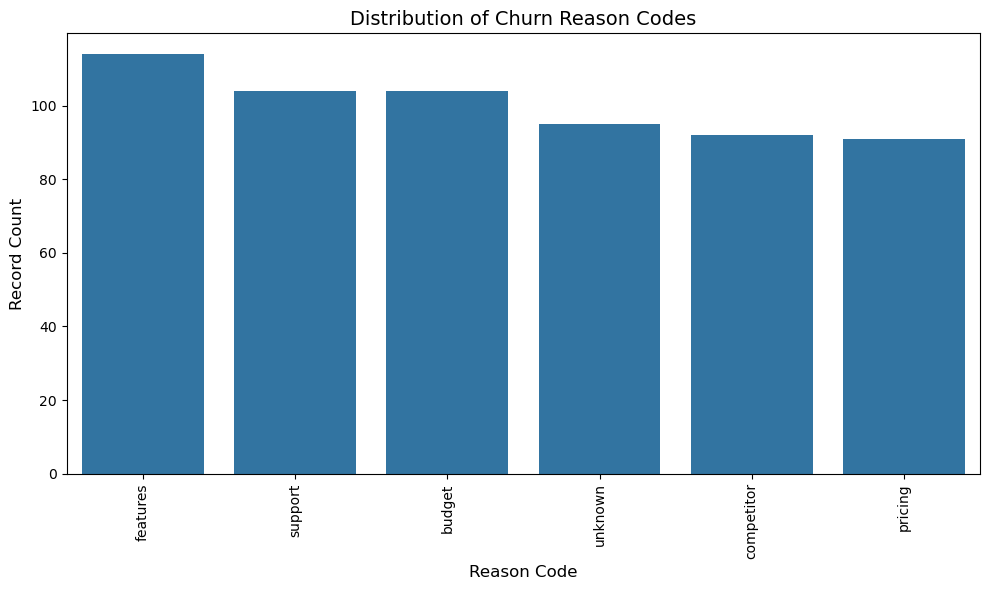

In [48]:
# Countplot to view distribution of churn reason codes
export_countplot(
    df=chur,
    column='reason_code',
    filename='churn_reason_code_distribution.png',
    title='Distribution of Churn Reason Codes',
    xlabel='Reason Code',
    ylabel='Record Count'
)

In [49]:
# View counts of churn reason codes
chur['reason_code'].value_counts()

reason_code
features      114
support       104
budget        104
unknown        95
competitor     92
pricing        91
Name: count, dtype: int64

#### 4.1.2 Churn event EDA observations and next actions
Evidence of the synthetic nature of the data, the distribution of reasons codes for customer attrition is very evenly distributed.
There are almost as many 'unknown' as any other reason. There is very little that is actionable here and these insights should not be prioritised.

With limited intel from historical churn, I do not expect strong signals from the early iterations of a churn prediction model.
Continue to analyse churn event data using Natural Language Processing (NLP) on Feedback text (free text, not nominal drop down selections) to derive insights not provided in "Reason Code" selections.

#### 4.1.3 Sentiment analysis of churn event feedback text 

In [50]:
# Create a copy of churn events for NLP
chur_nlp = chur.copy()

In [51]:
# Remove null values from 'feedback_text' column
chur_nlp['feedback_text'] = chur_nlp['feedback_text'].fillna('')

In [52]:
# Reset index after removing nulls
chur_nlp = chur_nlp.reset_index(drop=True)

In [53]:
# Calculate VADER compound sentiment scores
chur_nlp['feedback_sentiment'] = chur_nlp['feedback_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

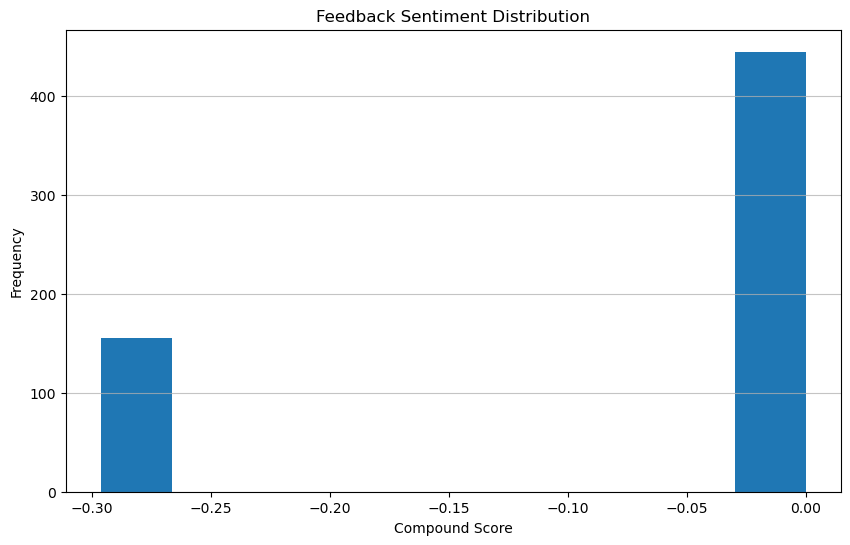

In [54]:
# Histogram of compound sentiment scores
export_sentiment_hist(
    df=chur_nlp,
    column='feedback_sentiment',
    filename='feedback_sentiment.png',
    title='Feedback Sentiment Distribution',
    xlabel='Compound Score'
)

#### 4.1.4 Churn event reason code and feedback text comparison

In [55]:
# Create working copy for churn feedback analysis
chur_analysis = chur.copy()

In [56]:
# Map existing reason code to potential keywords in feedback text (omit 'unknown'
reason_keywords = {
    'pricing': ['price', 'cost', 'expensive', 'cheaper', 'pricing'],
    'support': ['support', 'help', 'response', 'slow', 'unhelpful'],
    'budget': ['budget', 'cut', 'saving', 'finance'],
    'product': ['feature', 'missing', 'capability', 'does not', 'cannot'],
    'competitor': ['competitor', 'switched to', 'alternative', 'other vendor']
}

In [57]:
# Create column for reason code/feedback text matching
chur_analysis['feedback_matches_reason'] = chur_analysis.apply(
    lambda row: feedback_matches_reason(row['feedback_text'], row['reason_code']),
    axis=1
)

In [58]:
# Filter to rows with feedback text and a known reason code, excluding 'unknown'
valid_rows = chur_analysis[
    chur_analysis['feedback_text'].notna() & (chur['reason_code'] != 'unknown')
]

In [59]:
# Percentage of rows where feedback does NOT match the reason code
mismatch_rate = 1 - valid_rows['feedback_matches_reason'].mean()

print(f"Rows analysed (feedback present, known reason): {len(valid_rows)}")
print(f"Mismatch rate: {mismatch_rate:.1%}")

Rows analysed (feedback present, known reason): 379
Mismatch rate: 87.9%


In [60]:
# Display rows where feedback exists but does not match the reason code
chur_analysis[
    chur_analysis['feedback_text'].notna() & 
    (chur_analysis['feedback_matches_reason'] == False)
][['reason_code', 'feedback_text']].head(10)

,reason_code,feedback_text
0,pricing,switched to competitor
2,budget,missing features
3,budget,switched to competitor
5,features,missing features
8,features,too expensive
9,features,switched to competitor
10,features,too expensive
13,features,switched to competitor
15,pricing,switched to competitor
16,budget,too expensive


#### 4.1.4 Churn event EDA and NLP observations and next actions

Feedback is negative. Mostly 'slightly negative' ~450 between -0,05 and 0 and all the remaining reviews are at the extreme end of the scale between -0.3 and -0.25.

There is no compound scores at all between these two extremes. Another indication of the artificial nature of ths data set.

There is a very high proportion of conflicts between 'reason_code' and 'feedback_text' - 88%. This is a symptom of a data set created artificially. If this was found in the real world, make suggestions to ensure the intel obtained from exiting customers is consistent.

### 4.2 Revenue EDA

#### 4.2.1 Merge subscriptions and accounts tables 

Calculate revenue totals and explore categorical data further

In [61]:
# Check column names for potential duplicates
print(subs.columns)
print(raccs.columns)

Index(['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier',
       'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag',
       'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag'],
      dtype='object')
Index(['account_id', 'account_name', 'industry', 'country', 'signup_date',
       'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag'],
      dtype='object')


In [62]:
# Make copy of raccs with just the required columns to prepare for merge
raccs_clean = raccs[['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source']].copy()

# Merge subscriptions and accounts
subs_accounts = subs.merge(raccs_clean, on='account_id', how='left')

In [63]:
# Familiarisation - column and row counts
subs_accounts.shape

(5000, 19)

In [64]:
# Familiarisation - summary of df including datatypes, nulls
subs_accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   subscription_id    5000 non-null   object        
 1   account_id         5000 non-null   object        
 2   start_date         5000 non-null   datetime64[ns]
 3   end_date           486 non-null    datetime64[ns]
 4   plan_tier          5000 non-null   object        
 5   seats              5000 non-null   int64         
 6   mrr_amount         5000 non-null   int64         
 7   arr_amount         5000 non-null   int64         
 8   is_trial           5000 non-null   bool          
 9   upgrade_flag       5000 non-null   bool          
 10  downgrade_flag     5000 non-null   bool          
 11  churn_flag         5000 non-null   bool          
 12  billing_frequency  5000 non-null   object        
 13  auto_renew_flag    5000 non-null   bool          
 14  account_

In [65]:
# Find accounts with multiple subscriptions
multi_subs = subs_accounts[subs_accounts.duplicated(subset=['account_id'], keep=False)]

In [66]:
# Pick one account_id and inspect
sample_account = multi_subs['account_id'].iloc[0]
subs_accounts[subs_accounts['account_id'] == sample_account]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,account_name,industry,country,signup_date,referral_source
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True,Company_224,DevTools,UK,2023-08-26,event
104,S-2214c6,A-3c1a3f,2024-10-07,NaT,Pro,82,4018,48216,False,False,False,False,monthly,True,Company_224,DevTools,UK,2023-08-26,event
701,S-a10eb2,A-3c1a3f,2023-08-31,NaT,Basic,45,0,0,True,False,False,False,annual,False,Company_224,DevTools,UK,2023-08-26,event
1213,S-e9737c,A-3c1a3f,2023-12-28,NaT,Enterprise,29,5771,69252,False,False,False,False,monthly,True,Company_224,DevTools,UK,2023-08-26,event
1651,S-e6b35a,A-3c1a3f,2024-03-25,NaT,Basic,4,76,912,False,False,False,False,monthly,True,Company_224,DevTools,UK,2023-08-26,event
2824,S-a99771,A-3c1a3f,2023-12-18,NaT,Basic,25,0,0,True,False,False,False,annual,True,Company_224,DevTools,UK,2023-08-26,event
3014,S-511e50,A-3c1a3f,2024-10-13,NaT,Enterprise,1,199,2388,False,False,False,False,annual,True,Company_224,DevTools,UK,2023-08-26,event
3144,S-4ad7b1,A-3c1a3f,2024-04-28,NaT,Enterprise,2,398,4776,False,False,True,False,monthly,True,Company_224,DevTools,UK,2023-08-26,event
3239,S-715ace,A-3c1a3f,2023-12-29,NaT,Pro,1,0,0,True,False,False,False,annual,True,Company_224,DevTools,UK,2023-08-26,event
3826,S-5856ab,A-3c1a3f,2024-05-06,2024-11-25,Pro,19,931,11172,False,False,False,True,annual,True,Company_224,DevTools,UK,2023-08-26,event


#### 4.2.2 Account-Subscription Complexity Observations

- One account can have multiple subscriptions (example: account_id A-3c1a3f has 12 subscriptions)
- Subscriptions can overlap in time (active and churned subscriptions coexisting)
- Plans vary across subscriptions for the same account (Basic, Pro, Enterprise)
- Zero-dollar subscriptions (trials) appear alongside paid subscriptions
- Churned subscriptions exist on accounts that remain active overall

#### 4.2.3 Observations and next steps from revenue EDA

- Ignore zero-dollar (trial) subscriptions in revenue calculations and predictive model
- Potential upsell/consolidation opportunities where customers have subscriptions in different plan tiers

#### 4.2.4 Further revenue exploration

 - Use ARR not MRR due to volatility in churning subscriptions

 - ARR is a snap shot of annualised revenue from active subscriptions right now

In [67]:
# Subset paid subscriptions and create independent copy for reuse
paid_customers = subs_accounts[subs_accounts['is_trial'] == False].copy()

In [68]:
# Identify rows with maximum ARR for active subscriptions
# Who is our biggest customer?
paid_customers[paid_customers['arr_amount'] == paid_customers['arr_amount'].max()]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,account_name,industry,country,signup_date,referral_source
2245,S-78f738,A-c70870,2024-12-29,NaT,Enterprise,170,33830,405960,False,False,True,False,monthly,True,Company_253,Cybersecurity,US,2024-10-22,partner


In [69]:
# Calculate paid ARR of active subscriptions
print(paid_customers['arr_amount'].mean())

32227.608716248225


In [70]:
# Calculate total ARR of paid subscriptions
print(paid_customers['arr_amount'].sum())

136064964


In [71]:
# Make sure no revenue booked against trial subscriptions
trial_customers = subs_accounts[subs_accounts['is_trial'] == True].copy()

In [72]:
# Calculate total ARR of trial subscriptions (should be zero)
print(trial_customers['arr_amount'].sum())

0


#### 4.2.5 Lost revenue
Explore cost of churn

In [73]:
# Subset inactive subscriptions to analyse churned revenue
churned_subs = subs_accounts[subs_accounts['churn_flag'] == True].copy()

In [74]:
# Establish number of churned subscriptions
churned_subs.shape

(486, 19)

In [75]:
# Calculate total ARR of inactive subscriptions
print(churned_subs['arr_amount'].sum())

14149668


In [76]:
# Active subscription was 121915296 ARR. Obtain active/inactive ARR total to make sure the numbers add uo
print(subs_accounts['arr_amount'].sum())

136064964


In [77]:
#Establish date range of activity to calculate annualised churn (min start date)
print(subs_accounts['start_date'].min())

2023-01-09 00:00:00


In [78]:
#Establish date range of activity to calculate annualised churn (max end date)
print(subs_accounts['end_date'].max())

2024-12-31 00:00:00


#### 4.2.6 Lost revenue summary

136064964 - 14149668 = 121915296

During two years (Jan 2023 - Dec 2024) churn ARR = approximately 10%

In case study, describe 5% Annualised churn

### 4.3 Plan tiers

#### 4.3.1 Plan tier analysis
The plan tiers look remarkably even. Remove trial subscriptions to see how much noise they create

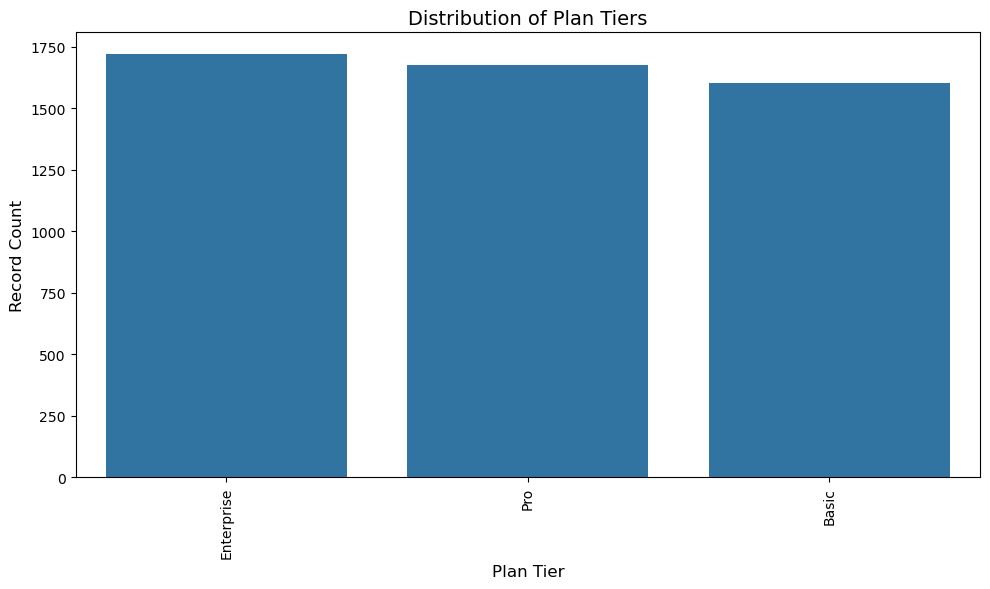

In [79]:
# Check distribution of tiers for all subscriptions
export_countplot(
    df=subs_accounts,
    column='plan_tier',
    filename='plan_tiers_all_subscriptions.png',
    title='Distribution of Plan Tiers',
    xlabel='Plan Tier',
    ylabel='Record Count'
)

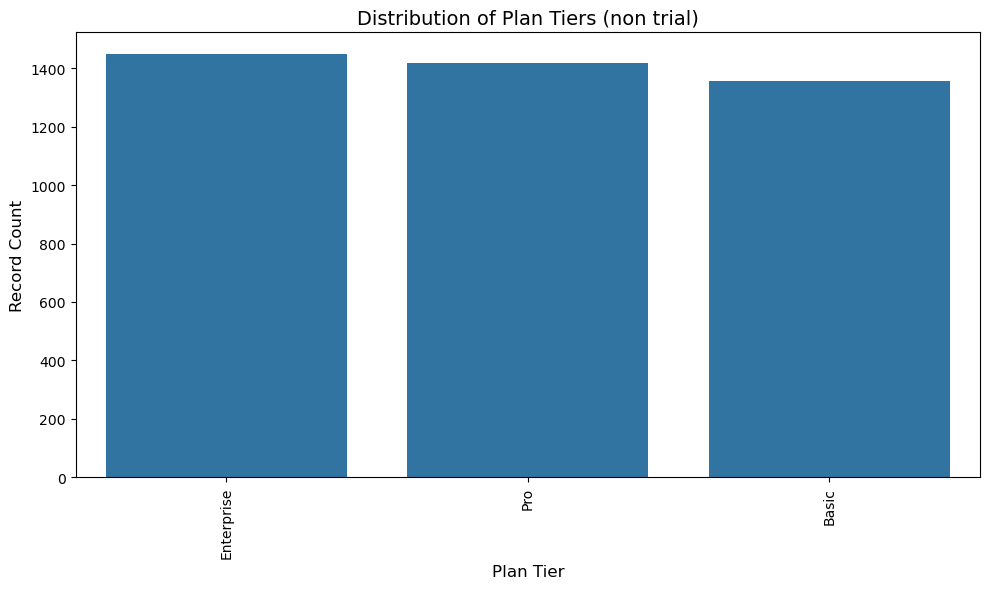

In [80]:
# Compare with plan distribution for non-trial subscriptions
export_countplot(
    df=paid_customers,
    column='plan_tier',
    filename='plan_tiers_paying_subscriptions.png',
    title='Distribution of Plan Tiers (non trial)',
    xlabel='Plan Tier',
    ylabel='Record Count'
)

#### 4.3.2 Plan tier observation
The without trial subscriptions,  plan tiers still look remarkably even. This is not a blocker, rather one of many indications of the synthetic nature of the data.

#### 4.3.3 Plan tier deep dive - Enterprise

In [81]:
# Subset non trial Enterprise subscriptions for analysis
paid_ent = paid_customers[paid_customers['plan_tier'] == 'Enterprise'].copy()

In [82]:
# Validate df by checking that the account with highest arr_amount within matches the 'biggest customer' globally
# Should match with result from row 61, above (account_if A-c70870)
paid_ent[paid_ent['arr_amount'] == paid_ent['arr_amount'].max()]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,account_name,industry,country,signup_date,referral_source
2245,S-78f738,A-c70870,2024-12-29,NaT,Enterprise,170,33830,405960,False,False,True,False,monthly,True,Company_253,Cybersecurity,US,2024-10-22,partner


In [83]:
# With trials filtered out, check minimum ARR subscriptions in every plan tier
# Start with Enterprise
paid_ent[paid_ent['arr_amount'] == paid_ent['arr_amount'].min()]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,account_name,industry,country,signup_date,referral_source
261,S-cb8a5c,A-1e6fc3,2024-12-17,NaT,Enterprise,1,199,2388,False,False,False,False,annual,True,Company_434,EdTech,FR,2023-12-06,other
1561,S-8fd22d,A-354f12,2024-08-01,NaT,Enterprise,1,199,2388,False,False,False,False,monthly,True,Company_201,FinTech,US,2024-04-28,ads
1626,S-fc155b,A-ccabf0,2024-09-09,NaT,Enterprise,1,199,2388,False,False,False,False,annual,True,Company_471,HealthTech,IN,2023-11-06,organic
2454,S-ea3d54,A-439b2f,2024-05-30,NaT,Enterprise,1,199,2388,False,False,False,False,monthly,False,Company_152,DevTools,US,2024-02-21,ads
3014,S-511e50,A-3c1a3f,2024-10-13,NaT,Enterprise,1,199,2388,False,False,False,False,annual,True,Company_224,DevTools,UK,2023-08-26,event
3195,S-36069b,A-940b8b,2024-06-26,NaT,Enterprise,1,199,2388,False,False,False,False,annual,True,Company_398,HealthTech,DE,2024-03-19,organic
4239,S-0b8b0c,A-f17767,2024-08-03,NaT,Enterprise,1,199,2388,False,False,False,False,monthly,False,Company_123,DevTools,US,2023-01-30,event


#### 4.3.4 Enterprise plan observations

This is sufficient to proceed with k-means clustering to seek out disctinct segments. Currently, plan_tier is the only ordinal/categorical data to size customers. Another method is to report on revenue metrics and seats owned. Clustering would group accounts along categorical and revenue lines resulting in targeted initiatives, resource allocation and prioritisation.

Check other plan tiers before proceeding on to clustering EDA.

#### 4.3.5 Plan tier deep dive - Pro

In [84]:
# Subset non trial Pro subscriptions for analysis
paid_pro = paid_customers[paid_customers['plan_tier'] == 'Pro'].copy()

In [85]:
# Identify rows with maximum ARR for active subscriptions for paying Pro tier subscriptions
# Compare with Enterprise revenues for further validation of the observations about a process gap in segmentation
paid_pro[paid_pro['arr_amount'] == paid_pro['arr_amount'].max()]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,account_name,industry,country,signup_date,referral_source
2353,S-e11518,A-3ce5b8,2023-12-15,NaT,Pro,189,9261,111132,False,False,False,False,annual,True,Company_256,FinTech,IN,2023-09-07,ads


In [86]:
# Observe minimum ARR subscriptions for Pro plan tier
paid_pro[paid_pro['arr_amount'] == paid_pro['arr_amount'].min()]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,account_name,industry,country,signup_date,referral_source
94,S-367dee,A-e19ff6,2024-06-29,NaT,Pro,1,49,588,False,False,False,False,annual,True,Company_411,Cybersecurity,UK,2023-07-28,partner
216,S-aa20eb,A-6f8ad2,2024-09-08,NaT,Pro,1,49,588,False,False,False,False,monthly,False,Company_57,EdTech,IN,2024-07-09,organic
2742,S-0f7a92,A-700ade,2024-12-23,NaT,Pro,1,49,588,False,False,False,False,monthly,False,Company_472,Cybersecurity,UK,2024-10-31,organic
2869,S-c52d77,A-6e7827,2023-11-05,NaT,Pro,1,49,588,False,True,False,False,monthly,False,Company_372,DevTools,US,2023-03-26,other
2919,S-09c1df,A-b7724f,2024-09-15,2024-10-02,Pro,1,49,588,False,False,False,True,annual,True,Company_320,HealthTech,UK,2023-03-28,organic
2961,S-1261fb,A-fd7ad3,2024-11-29,NaT,Pro,1,49,588,False,False,False,False,monthly,False,Company_100,Cybersecurity,US,2024-11-01,event
2962,S-561d54,A-0a282f,2024-11-10,NaT,Pro,1,49,588,False,False,False,False,annual,True,Company_2,DevTools,US,2024-08-27,organic
3036,S-06447b,A-17939a,2024-12-27,NaT,Pro,1,49,588,False,False,False,False,annual,True,Company_162,HealthTech,US,2024-12-26,organic
3604,S-b120fb,A-f51f16,2024-04-01,2024-08-23,Pro,1,49,588,False,False,False,True,annual,False,Company_282,HealthTech,US,2023-12-25,partner
4123,S-2881e0,A-42e5e1,2024-07-21,NaT,Pro,1,49,588,False,False,True,False,annual,True,Company_118,DevTools,US,2024-07-09,ads


#### 4.3.6 Pro plan observations

Further justifcation for segmentation and upsell recommendations

 - Largest Pro plan subscription paying Enterprise subscription fees (> $100k)

 - Many with 1 seat and paying $588 ARR

#### 4.3.7 Plan tier deep dive - Basic

In [87]:
# Subset non trial Pro subscriptions for analysis
paid_basic = paid_customers[paid_customers['plan_tier'] == 'Basic'].copy()

In [88]:
# Identify rows with maximum ARR for active Basic subscriptions
# Compare with Enterprise & Pro revenues
paid_basic[paid_basic['arr_amount'] == paid_basic['arr_amount'].max()]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,account_name,industry,country,signup_date,referral_source
710,S-c8fa77,A-56962b,2024-08-28,NaT,Basic,163,3097,37164,False,False,False,False,monthly,True,Company_177,EdTech,UK,2024-04-09,partner
3002,S-4970c1,A-56962b,2024-09-03,NaT,Basic,163,3097,37164,False,False,False,False,annual,True,Company_177,EdTech,UK,2024-04-09,partner


In [89]:
# Observe minimum ARR subscriptions for Basic plan tier
paid_basic[paid_basic['arr_amount'] == paid_basic['arr_amount'].min()]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,account_name,industry,country,signup_date,referral_source
1604,S-4047a8,A-e19ff6,2024-06-01,NaT,Basic,1,19,228,False,False,False,False,monthly,False,Company_411,Cybersecurity,UK,2023-07-28,partner
1996,S-d19797,A-fd7ad3,2024-11-10,NaT,Basic,1,19,228,False,False,False,False,monthly,True,Company_100,Cybersecurity,US,2024-11-01,event
2007,S-c2b60b,A-5a184f,2024-10-20,NaT,Basic,1,19,228,False,False,False,False,annual,True,Company_124,DevTools,DE,2023-06-19,other
2513,S-ccf9c8,A-956988,2024-12-14,NaT,Basic,1,19,228,False,False,False,False,monthly,False,Company_14,EdTech,UK,2024-11-30,ads
3673,S-8d4b81,A-2b9d3e,2024-04-28,NaT,Basic,1,19,228,False,False,False,False,annual,False,Company_319,EdTech,US,2023-06-04,partner
3728,S-e77d56,A-9289f6,2023-12-06,NaT,Basic,1,19,228,False,False,False,False,monthly,True,Company_104,EdTech,US,2023-05-31,event
3839,S-860bc8,A-42e5e1,2024-08-29,NaT,Basic,1,19,228,False,False,False,False,annual,True,Company_118,DevTools,US,2024-07-09,ads
4641,S-bbc0f7,A-b7724f,2024-09-15,NaT,Basic,1,19,228,False,False,False,False,annual,True,Company_320,HealthTech,UK,2023-03-28,organic


#### 4.3.8 Basic plan observations
Nothing added from evaluation of Enterprise and Pro plans 

## 5 Segmentation

### 5.1 Segmentation EDA - First attempt
Identify features for clustering using K-means.

#### 5.1.1 Summary of Segmentation EDA steps taken

Previous drafts of this notebook conatin exhaustive explorative analysis attempting to idenfity combinations of revenue based and behavourial features to observe customers in distinct groups that can be characterised and prioritised.
Because this is a completely artificial data set, those clusters did not emmerge in analysis. One example of that work is retained below (industry + arr) with all other attempts available in an earlier draft named 'RavenStack_2.ipynb', which can also be found in this repository.

As a proxy, I fall back on total arr + seat count to create two clusters. Without some level of segmentation, prioritisation and resource assignment is particularly challenging. This revenue based workaround exists to allow for prioritisation of actions and recommendations in subsequent sections of this workflow. 

#### 5.1.2  Industry and ARR - correlation attempt

In [90]:
# Remind yourself of columns in the 'non-trial subscriptions df'
paid_customers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4222 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   subscription_id    4222 non-null   object        
 1   account_id         4222 non-null   object        
 2   start_date         4222 non-null   datetime64[ns]
 3   end_date           408 non-null    datetime64[ns]
 4   plan_tier          4222 non-null   object        
 5   seats              4222 non-null   int64         
 6   mrr_amount         4222 non-null   int64         
 7   arr_amount         4222 non-null   int64         
 8   is_trial           4222 non-null   bool          
 9   upgrade_flag       4222 non-null   bool          
 10  downgrade_flag     4222 non-null   bool          
 11  churn_flag         4222 non-null   bool          
 12  billing_frequency  4222 non-null   object        
 13  auto_renew_flag    4222 non-null   bool          
 14  account_name 

In [91]:
# Aggegate arr and seat counts, grouping by account_id for account totals
account_totals = paid_customers.groupby('account_id').agg(
    total_arr=('arr_amount', 'sum'),
    total_seats=('seats', 'sum')
).reset_index()

In [92]:
# Inspect results
account_totals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   account_id   500 non-null    object
 1   total_arr    500 non-null    int64 
 2   total_seats  500 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 11.8+ KB


In [93]:
# Merge revenue/seat totals with accounts df
account_totals = account_totals.merge(raccs, on='account_id', how='left')

In [94]:
# Inspect results
account_totals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   account_id       500 non-null    object        
 1   total_arr        500 non-null    int64         
 2   total_seats      500 non-null    int64         
 3   account_name     500 non-null    object        
 4   industry         500 non-null    object        
 5   country          500 non-null    object        
 6   signup_date      500 non-null    datetime64[ns]
 7   referral_source  500 non-null    object        
 8   plan_tier        500 non-null    object        
 9   seats            500 non-null    int64         
 10  is_trial         500 non-null    bool          
 11  churn_flag       500 non-null    bool          
dtypes: bool(2), datetime64[ns](1), int64(3), object(6)
memory usage: 40.2+ KB


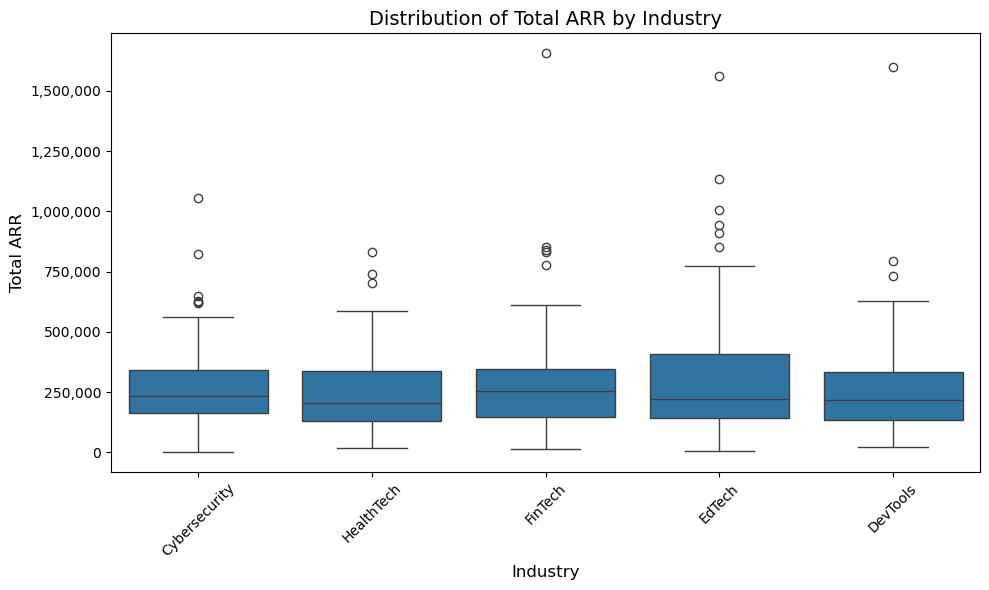

In [95]:
export_boxplot(
    df=account_totals,
    x='industry',
    y='total_arr',
    filename='industry_arr_box.png',
    title='Distribution of Total ARR by Industry',
    xlabel='Industry',
    ylabel='Total ARR'
)

In [96]:
# Obtain statistics to accompany above visual
industry_arr_stats = account_totals.groupby('industry')['total_arr'].describe()
print(industry_arr_stats)

               count           mean            std      min       25%  \
industry                                                                
Cybersecurity  100.0  270398.160000  170466.028687   2280.0  162321.0   
DevTools       113.0  255255.292035  198284.201237  21552.0  133044.0   
EdTech          79.0  310354.481013  281222.617975   5328.0  143148.0   
FinTech        112.0  286017.428571  217622.175093  14136.0  144378.0   
HealthTech      96.0  246139.000000  163923.743192  18720.0  130512.0   

                    50%       75%        max  
industry                                      
Cybersecurity  231774.0  339711.0  1055484.0  
DevTools       217584.0  333180.0  1599576.0  
EdTech         219780.0  407988.0  1561824.0  
FinTech        253584.0  344235.0  1656720.0  
HealthTech     204924.0  339183.0   830208.0  


#### 5.1.3 Observations on potential clusters by industry + arr
 - Standard deviations are large

 - Means and medians are close across industries

 - Industry + arr shows wide internal variation and overlapping distributions, suggesting little value for segmentation

As mentioned above, this lack of distinct groupings was repeated in different selections of columns from the source data due to its synthetic nature. This workflow continues straight to the proxy to group by total arr and total seats as a workable, temporary solution.

### 5.2 Segmentation EDA - Work around

#### 5.2.1 Observe relationship between ARR totals and total seats

In [97]:
# Create a fresh dataframe for ARR + seats segmentation
cluster_final = account_totals[['account_id', 'total_arr', 'total_seats']].copy()

In [98]:
cluster_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   account_id   500 non-null    object
 1   total_arr    500 non-null    int64 
 2   total_seats  500 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 11.8+ KB


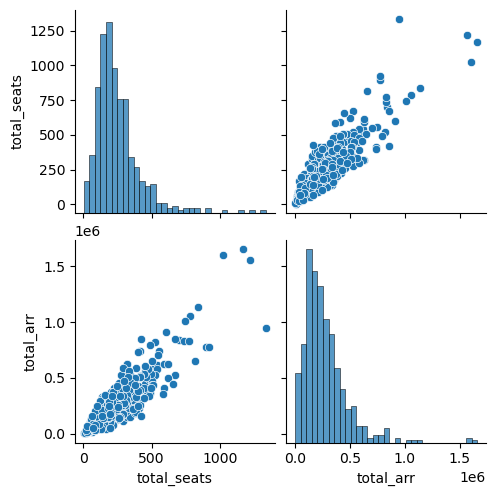

In [99]:
# Create a pairplot with Seaborn and export as png
x = cluster_final[['total_seats', 'total_arr']]
pairplot = sns.pairplot(cluster_final, vars=x)
pairplot.savefig('pairplot_final.png', dpi=300)

#### 5.2.2 Use Kmeans Elbow Method to surface distinct clusters

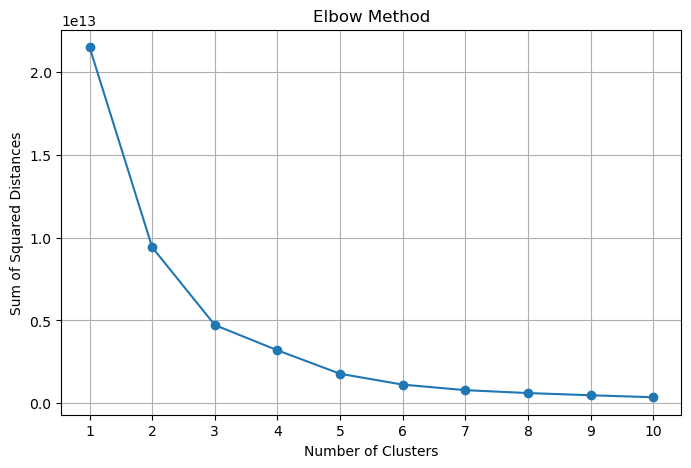

In [100]:
# Elbow method to identify separation
# Define x (only total_arr and total seats in df) 
x = cluster_final[['total_arr', 'total_seats']]

# Elbow method code
ss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x)
    ss.append(kmeans.inertia_)

# Plot it
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), ss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Sum of Squared Distances")
plt.grid(True)
plt.xticks(range(1, 11))
plt.savefig('elbow_final.png', dpi=300, bbox_inches='tight')
plt.show()

#### 5.2.3 Obtain silhouette scores to verify number of clusters

In [101]:
# Generate silhouette scores to resolve whether bend there are 2 or 3 clusters
x = cluster_final[['total_arr', 'total_seats']]

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x)
    score = silhouette_score(x, labels)
    print(f"k={k}, silhouette score={score:.3f}")

k=2, silhouette score=0.654
k=3, silhouette score=0.597
k=4, silhouette score=0.540
k=5, silhouette score=0.541


#### 5.2.4 KMeans observations and next steps

- Elbow appears to indicate k=3

- Silhoute indicates k=2

- Proceed with two segments (higher value and lower value customers)

#### 5.2.5 Fit KMeans and view results

In [102]:
# Fit k-means with 2 clusters (final model)
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_final['cluster'] = kmeans.fit_predict(cluster_final[['total_arr', 'total_seats']])

# Check cluster centre statistics
print(kmeans.cluster_centers_)

[[6.33704615e+05 5.06025641e+02]
 [2.05298588e+05 2.04011848e+02]]


#### 5.2.6 Cluster centre analysis
 
 - Cluster 0 has higher ARR (approx 634k) and seats ( approx 506): label as 'Premier'

 - Cluster 1 has lower ARR (approx 205k) and seats ( approx 204): label as 'Core'

#### 5.2.7 Segment labelling

In [103]:
# Map cluster numbers to segment names
cluster_final['segment'] = cluster_final['cluster'].map({0: 'Premier', 1: 'Core'})

In [104]:
cluster_final.head()

,account_id,total_arr,total_seats,cluster,segment
0,A-00bed1,402072,314,1,Core
1,A-00cac8,169452,129,1,Core
2,A-0158bb,48840,110,1,Core
3,A-016043,198192,154,1,Core
4,A-019782,100236,97,1,Core


#### 5.2.8 Customer segmentation results

In [105]:
# Observe distritbution of segments
cluster_final['segment'].value_counts()

segment
Core       422
Premier     78
Name: count, dtype: int64

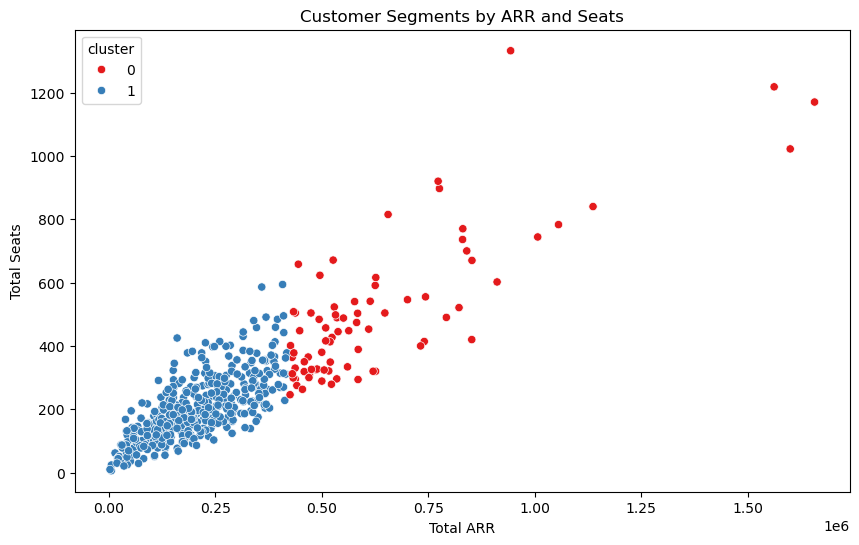

In [106]:
# Scatterplot with clusters coloured
export_scatter(
    df=cluster_final,
    x='total_arr',
    y='total_seats',
    hue='cluster',
    filename='scatterplot_arr_seats_final.png',
    title='Customer Segments by ARR and Seats',
    xlabel='Total ARR',
    ylabel='Total Seats'
)

#### 5.2.9 Customer segmentations conclusions and next steps

The resulting dataframe 'cluster_final' can be merged to 'accounts level' customer lists and the results of the following models.
This will allow resources to be assigned and prioritisation of actions to each group in the hierarchy;

 - Premier customers to receive named CSM resources and high touch, personal service
 - Core customers to be assigned to pooled CSM resources and increased automation

## 6 Health scoring

We are using data from Feature Usage and Support Tickets for this framework. Support Tickets does not include subsciption_ids, for some reason, it is only recorded at account level, which is a flaw and a limitation. For that reason, will need to wrangle feature usage data to aggregate to account level before merging with support ticket data.

### 6.1 Prepare usage and support ticket data

#### 6.1.1 Merge and aggregate from source data

In [107]:
# Merge usage and subscription data
usage_subs = paid_customers.merge(fuse, on='subscription_id', how='left')

In [108]:
# Group usage data by subscription_id to create one row per subscription
usage_account = usage_subs.groupby('account_id').agg(
    avg_usage_count=('usage_count', 'mean'),
    distinct_features=('feature_name', 'nunique')
    ).reset_index()

In [109]:
usage_account.head()

,account_id,avg_usage_count,distinct_features
0,A-00bed1,10.304348,29
1,A-00cac8,10.529412,30
2,A-0158bb,10.000000,15
3,A-016043,10.282051,24
4,A-019782,10.434783,25


In [110]:
# Support ticket data has nulls where there was no response to satisfaction survey
# First create a copy df to use for imputation
stix_clean = stix.copy()

In [111]:
# Calculate customer mean satisfaction, ignoring nulls
customer_sat_mean = stix_clean.groupby('account_id')['satisfaction_score'].transform('mean')

In [112]:
# Calculate the global satisfaction mean to obtain a value for customers with no score recorded
global_sat_mean = stix_clean['satisfaction_score'].mean()

In [113]:
# Create a new column "sat_score" which will contain either the account mean or the global mean if no score available
stix_clean['sat_score'] = stix_clean['satisfaction_score'].fillna(customer_sat_mean).fillna(global_sat_mean)

In [114]:
stix_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ticket_id                    2000 non-null   object        
 1   account_id                   2000 non-null   object        
 2   submitted_at                 2000 non-null   datetime64[ns]
 3   closed_at                    2000 non-null   datetime64[ns]
 4   resolution_time_hours        2000 non-null   float64       
 5   priority                     2000 non-null   object        
 6   first_response_time_minutes  2000 non-null   int64         
 7   satisfaction_score           1175 non-null   float64       
 8   escalation_flag              2000 non-null   bool          
 9   sat_score                    2000 non-null   float64       
dtypes: bool(1), datetime64[ns](2), float64(3), int64(1), object(3)
memory usage: 142.7+ KB


In [115]:
# Aggregate support metrics to account level (one row per account)
support_agg = stix_clean.groupby('account_id').agg(
    total_tickets=('ticket_id', 'count'),
    avg_resolution_hours=('resolution_time_hours', 'mean'),
    avg_sat_score=('sat_score', 'mean')
).reset_index()

In [116]:
support_agg.head()

,account_id,total_tickets,avg_resolution_hours,avg_sat_score
0,A-00bed1,4,31.750000,4.000000
1,A-00cac8,2,33.000000,3.981277
2,A-0158bb,1,32.000000,3.000000
3,A-016043,3,30.333333,4.000000
4,A-019782,2,10.000000,3.000000


In [117]:
# Merge usage totals with ticket totals
health_data = usage_account.merge(support_agg, on='account_id', how='left')

In [118]:
health_data.head()

,account_id,avg_usage_count,distinct_features,total_tickets,avg_resolution_hours,avg_sat_score
0,A-00bed1,10.304348,29,4.0,31.750000,4.000000
1,A-00cac8,10.529412,30,2.0,33.000000,3.981277
2,A-0158bb,10.000000,15,1.0,32.000000,3.000000
3,A-016043,10.282051,24,3.0,30.333333,4.000000
4,A-019782,10.434783,25,2.0,10.000000,3.000000


In [119]:
# Check for any remaining nulls
health_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   account_id            500 non-null    object 
 1   avg_usage_count       500 non-null    float64
 2   distinct_features     500 non-null    int64  
 3   total_tickets         492 non-null    float64
 4   avg_resolution_hours  492 non-null    float64
 5   avg_sat_score         492 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 23.6+ KB


In [120]:
# Fill support data nulls with 0 (no tickets raised = zero support activity)
health_data['total_tickets'] = health_data['total_tickets'].fillna(0)
health_data['avg_resolution_hours'] = health_data['avg_resolution_hours'].fillna(0)
health_data['avg_sat_score'] = health_data['avg_sat_score'].fillna(0)

In [121]:
# Inspect results
health_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   account_id            500 non-null    object 
 1   avg_usage_count       500 non-null    float64
 2   distinct_features     500 non-null    int64  
 3   total_tickets         500 non-null    float64
 4   avg_resolution_hours  500 non-null    float64
 5   avg_sat_score         500 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 23.6+ KB


#### 6.1.2 Normalise collected data

In [122]:
# Create a copy form normalisation
health_data_scaled = health_data.copy()

In [123]:
# Select columns to normalise
norm_cols = [
    'avg_usage_count', 'distinct_features', 'total_tickets', 'avg_resolution_hours', 'avg_sat_score'
]

In [124]:
# Apply MinMaxScaler
scaler = MinMaxScaler()
health_data_scaled[norm_cols] = scaler.fit_transform(health_data[norm_cols])

In [125]:
# Inspect results
health_data_scaled.head()

,account_id,avg_usage_count,distinct_features,total_tickets,avg_resolution_hours,avg_sat_score
0,A-00bed1,0.771299,0.729730,0.363636,0.440972,0.800000
1,A-00cac8,0.811629,0.756757,0.181818,0.458333,0.796255
2,A-0158bb,0.716763,0.351351,0.090909,0.444444,0.600000
3,A-016043,0.767304,0.594595,0.272727,0.421296,0.800000
4,A-019782,0.794672,0.621622,0.181818,0.138889,0.600000


In [126]:
# Check dtypes and for any remaining nulls
health_data_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   account_id            500 non-null    object 
 1   avg_usage_count       500 non-null    float64
 2   distinct_features     500 non-null    float64
 3   total_tickets         500 non-null    float64
 4   avg_resolution_hours  500 non-null    float64
 5   avg_sat_score         500 non-null    float64
dtypes: float64(5), object(1)
memory usage: 23.6+ KB


### 6.2 Weighting

#### 6.2.1 Health Score Weighting Summary

Geoffrey Weiss's white paper provides this example that weighting a health scoring framework might include

 - Product usage (depth and breadth): 30%
 - Executive engagement frequency: 25%
 - Support ticket volume and sentiment: 15%
 - Contract renewal timeline: 10%
 - User growth/adoption rates: 10%
 - Invoice payment history: 10%

The data does not provide;

 - Executive engagement. The only survey appears to be on closure of support ticket.  User level satisfaction is the only level of customer engagement captured.
 - Billing metrics (Contract renewal timeline & Invoice payment history). No data provided.

For V1, health scoring will be weighted as follows, based on the available data:

Usage (50%)
 - distinct_features (Usage depth): 25%
 - avg_usage_count (Usage breadth): 25%

Support (50%)
 - avg_sat_score: 30%
 - total_tickets: 10%
 - avg_resolution_hours: 10%

50/50 split Usage and Support. Rationale without the aforementioned measures, we can only gather usage breadth and depth and use support activity as a proxy for all customer engagement. 

#### 6.2.2 apply weighting to collected data

In [127]:
# Calculate health score using documented weighting
health_data_scaled['health_score'] = (
    # Product usage (50%)
    (health_data_scaled['distinct_features'] * 0.25) +
    (health_data_scaled['avg_usage_count'] * 0.25) +
    # Support (50%)
    (health_data_scaled['avg_sat_score'] * 0.30) +
    (health_data_scaled['total_tickets'] * 0.10) +
    (health_data_scaled['avg_resolution_hours'] * 0.10)
)

# Scale to 0-100
health_data_scaled['health_score'] = health_data_scaled['health_score'] * 100

In [128]:
health_data_scaled['health_score'].describe()

count    500.000000
mean      65.682510
std        7.743390
min       21.243375
25%       62.269857
50%       66.813991
75%       70.403928
max       80.463568
Name: health_score, dtype: float64

#### 6.2.3 Merge with output from clustering

In [129]:
# Bring in segment column
health_scoring = health_data_scaled.merge(cluster_final, on='account_id', how='left')

In [130]:
# Check df
health_scoring.head()

,account_id,avg_usage_count,distinct_features,total_tickets,avg_resolution_hours,avg_sat_score,health_score,total_arr,total_seats,cluster,segment
0,A-00bed1,0.771299,0.729730,0.363636,0.440972,0.800000,69.571812,402072,314,1,Core
1,A-00cac8,0.811629,0.756757,0.181818,0.458333,0.796255,69.498811,169452,129,1,Core
2,A-0158bb,0.716763,0.351351,0.090909,0.444444,0.600000,50.056394,48840,110,1,Core
3,A-016043,0.767304,0.594595,0.272727,0.421296,0.800000,64.987700,198192,154,1,Core
4,A-019782,0.794672,0.621622,0.181818,0.138889,0.600000,56.614412,100236,97,1,Core


In [131]:
# Retain key metrics only for this dataframe
health_scoring.drop(['avg_usage_count', 'distinct_features', 'total_tickets', 'avg_resolution_hours', 'cluster'], axis=1, inplace=True)

In [132]:
# Check finalised dataframe
health_scoring.head()

,account_id,avg_sat_score,health_score,total_arr,total_seats,segment
0,A-00bed1,0.800000,69.571812,402072,314,Core
1,A-00cac8,0.796255,69.498811,169452,129,Core
2,A-0158bb,0.600000,50.056394,48840,110,Core
3,A-016043,0.800000,64.987700,198192,154,Core
4,A-019782,0.600000,56.614412,100236,97,Core


In [133]:
# Obtain statistics for segments
health_scoring.groupby('segment')['health_score'].describe()

,count,mean,std,min,25%,50%,75%,max
segment,,,,,,,,
Core,422.0,65.289811,7.911976,21.243375,61.742435,66.427635,70.209152,80.463568
Premier,78.0,67.807113,6.394586,39.836319,65.248640,68.695746,71.244205,80.086893


#### 6.2.4 Health scoring conclusions
Health scores ranged from 21 to 80, with a mean of 66 and standard deviation 7.7. The tight distribution reflects the synthetic nature of the data; in a real-world dataset, we would expect wider variation and clearer differentiation between healthy and at-risk accounts.

Across segments, Premier has higher mean health (67.8 vs 65.3) and slightly lower variance (std 6.4 vs 7.9). That is consistent with what you would expect: higher-value accounts are healthier on average. However the differences are less pronounced than we may expect and likely another signal about the synthetic nature of this data.

## 7 Churn prediction

### 7.1 Data wrangling for predictive model

#### 7.1.1 Limitations of an artifical data set
Further to previous observations and documented obstacles provided in this data set, there more challenges during this process.
I have decided to overcome, workaround and document challenges in order to release a first iteration of a working predictive model and will be transparent about its shortcomings.
The earlier notebook 'RavenStack_2.ipynb' can also be found in this repo which contains earlier attempts of models with very weak signals and lower accuracy, precision and recall.
During my experiments, I found the best predictions came from using the date stamps in the Feature Usage tables to derive trend year on year combined with Support Ticket data (cumulative). When I attempted to trend the support ticket data, the signal weakened.

Note that feature usage is camptured at subscription level and support tickets only at account level so I cannot be 100% confident that support ticket data is captured for all subscriptions. Also note earlier problems documented in Feature Usage where dupicate IDs recorded activity from different subscription IDs.

In conclusion, this model is built on potentially incomplete and flawed data. In the real world I would advocate for shipping this model and making recommendations to collect fixed, accurate data and also to capture and share data that would strengthen the predictive power of the model in future iterations. These limitations and recommendations are documented in the Case Study doc.

#### 7.1.2 Create year-on-year trends from date stamped feature usage data

In [134]:
# Extract year from usage_date
fuse['usage_year'] = pd.to_datetime(fuse['usage_date']).dt.year

In [135]:
# Aggregate by subscription_id and year
usage_trends = fuse.groupby(['subscription_id', 'usage_year']).agg(
    total_usage_count=('usage_count', 'sum'),
    total_usage_duration=('usage_duration_secs', 'sum'),
    distinct_features=('feature_name', 'nunique'),
    total_errors=('error_count', 'sum')
).reset_index()

In [136]:
# Filter usage trends by year (2023 & 2024)
usage_2023 = usage_trends[usage_trends['usage_year'] == 2023].copy()
usage_2024 = usage_trends[usage_trends['usage_year'] == 2024].copy()

In [137]:
usage_2023.head()

,subscription_id,usage_year,total_usage_count,total_usage_duration,distinct_features,total_errors
0,S-001561,2023,40,18580,4,3
2,S-0027d3,2023,32,15096,2,0
4,S-003647,2023,59,10762,7,3
6,S-003fc0,2023,29,8937,3,0
8,S-004d19,2023,9,3996,1,0


In [138]:
paid_customers.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,account_name,industry,country,signup_date,referral_source
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True,Company_224,DevTools,UK,2023-08-26,event
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,False,False,monthly,True,Company_71,EdTech,AU,2023-09-28,other
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True,Company_295,Cybersecurity,US,2024-06-23,event
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,False,False,monthly,True,Company_154,FinTech,US,2023-10-29,ads
5,S-4b9b13,A-fa2041,2024-08-13,NaT,Pro,15,735,8820,False,False,False,False,monthly,True,Company_211,HealthTech,US,2024-05-29,organic


In [139]:
# Merge with subscriptions (non trial accounts) to get account_id
usage_2023 = usage_2023.merge(paid_customers[['subscription_id', 'account_id']], on='subscription_id', how='left')
usage_2024 = usage_2024.merge(paid_customers[['subscription_id', 'account_id']], on='subscription_id', how='left')

In [140]:
# Aggregate 2023 data by account
agg_2023 = usage_2023.groupby('account_id').agg(
    usage_count_2023=('total_usage_count', 'sum'),
    usage_duration_2023=('total_usage_duration', 'sum'),
    features_2023=('distinct_features', 'sum'),
    errors_2023=('total_errors', 'sum')
).reset_index()

In [141]:
# Aggregate 2024 data by account
agg_2024 = usage_2024.groupby('account_id').agg(
    usage_count_2024=('total_usage_count', 'sum'),
    usage_duration_2024=('total_usage_duration', 'sum'),
    features_2024=('distinct_features', 'sum'),
    errors_2024=('total_errors', 'sum')
).reset_index()

In [142]:
# Merge 2023 and 2024 data
account_trends = agg_2023.merge(agg_2024, on='account_id', how='outer')

In [143]:
account_trends.head()

,account_id,usage_count_2023,usage_duration_2023,features_2023,errors_2023,usage_count_2024,usage_duration_2024,features_2024,errors_2024
0,A-00bed1,205.0,49968.0,19.0,6.0,269.0,83883.0,27.0,19.0
1,A-00cac8,292.0,87901.0,27.0,14.0,245.0,60715.0,22.0,15.0
2,A-0158bb,140.0,55779.0,12.0,6.0,120.0,33963.0,12.0,8.0
3,A-016043,173.0,47373.0,18.0,8.0,228.0,49314.0,21.0,12.0
4,A-019782,228.0,60070.0,19.0,12.0,252.0,83052.0,24.0,13.0


In [144]:
# Calculations for trend columns
account_trends['usage_count_trend'] = account_trends['usage_count_2024'] - account_trends['usage_count_2023']
account_trends['usage_duration_trend'] = account_trends['usage_duration_2024'] - account_trends['usage_duration_2023']
account_trends['features_trend'] = account_trends['features_2024'] - account_trends['features_2023']
account_trends['errors_trend'] = account_trends['errors_2024'] - account_trends['errors_2023']

#### 7.1.3 Merge usage trends with support and account data to finalise the dataframe for predictive modelling

In [145]:
# Add arr_amount and seats from paid_customers (one value per account)
account_attributes = paid_customers[['account_id', 'arr_amount', 'seats']].drop_duplicates(subset='account_id')
account_trends = account_trends.merge(account_attributes, on='account_id', how='left')

In [146]:
# Merge account trends with aggregated support totals from Health Scoring
ch_predict = account_trends.merge(support_agg, on='account_id', how='left')

In [147]:
# Merge with accounts dataframe to get the 'churn_flag' column for 'y' target
ch_predict = ch_predict.merge(raccs[['account_id', 'churn_flag']], on='account_id', how='left')

In [148]:
# Check for nulls
ch_predict.isnull().sum()

account_id              0
usage_count_2023        1
usage_duration_2023     1
features_2023           1
errors_2023             1
usage_count_2024        1
usage_duration_2024     1
features_2024           1
errors_2024             1
usage_count_trend       2
usage_duration_trend    2
features_trend          2
errors_trend            2
arr_amount              0
seats                   0
total_tickets           8
avg_resolution_hours    8
avg_sat_score           8
churn_flag              0
dtype: int64

In [149]:
# Fill all nulls with 0
ch_predict = ch_predict.fillna(0)

In [150]:
# Check for nulls again
ch_predict.isnull().sum()

account_id              0
usage_count_2023        0
usage_duration_2023     0
features_2023           0
errors_2023             0
usage_count_2024        0
usage_duration_2024     0
features_2024           0
errors_2024             0
usage_count_trend       0
usage_duration_trend    0
features_trend          0
errors_trend            0
arr_amount              0
seats                   0
total_tickets           0
avg_resolution_hours    0
avg_sat_score           0
churn_flag              0
dtype: int64

### 7.2 Churn prediction

#### 7.2.1 Run the model 

 - Use SMOTE to blalance churn class to prevent bias towards non-churn
 - Gini to select splits amd create purer nodes
 - Max depth of 3 to avoid overfitting

In [151]:
# Define X (features) and y (target)
X = ch_predict.drop(['churn_flag', 'account_id'], axis=1)
y = ch_predict['churn_flag']

In [152]:
# Create a new DataFrame and apply SMOTE as the target variable is not balanced.
os = SMOTE(random_state=0)  

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=0)

# Specify column values.
columns = X_train.columns  
# Specify the new data sets.
os_data_X,os_data_y=os.fit_resample(X_train, y_train)  

# Create two DataFrames for X and one for y.
os_data_X = pd.DataFrame(data=os_data_X,columns=columns )
os_data_y= pd.DataFrame(data=os_data_y,columns=['churn_flag'])

# Print/check the DataFrame.
print("Length of oversampled data is ",len(os_data_X))
os_data_y

Length of oversampled data is  550


,churn_flag
0,True
1,False
2,False
3,False
4,False
...,...
545,True
546,True
547,True
548,True


In [153]:
# Determine if values in a column are balanced
os_data_y['churn_flag'].value_counts()

churn_flag
True     275
False    275
Name: count, dtype: int64

In [154]:
# Create a classification decision tree classifier object as dtc. 
dtc = DecisionTreeClassifier(criterion='gini',
                             max_depth=3,
                             random_state=1)

# Train the decision tree classifier.
dtc = dtc.fit(os_data_X, os_data_y) 

# Predict the response for the test data set.
y_pred = dtc.predict(X_test)

In [155]:
# How a lazy "nobody churns" model would perform (for comparison)
churn_rate = y_test.mean()
lazy_accuracy = 1 - churn_rate

print(f"Actual churn rate in test data: {churn_rate:.1%}")
print(f"Lazy model (predict 'no churn' for everyone) accuracy: {lazy_accuracy:.1%}")
print(f"Lazy model recall (catches actual churn): 0%")
print("-" * 40)

Actual churn rate in test data: 23.3%
Lazy model (predict 'no churn' for everyone) accuracy: 76.7%
Lazy model recall (catches actual churn): 0%
----------------------------------------


In [156]:
# Use the print() function to display the confusion matrix results.
print(confusion_matrix(y_test, y_pred))

# Metrics for accuracy: (TP + TN)/(TP + FP + TN + FN).
print("Accuracy:",metrics.accuracy_score(y_test, y_pred)) 

# Metrics for precision: TP/(TP + FP).
print("Precision:",metrics.precision_score(y_test, y_pred)) 

# Metrics for recall: TP/(FN + TP).
print("Recall:",metrics.recall_score(y_test, y_pred))

[[70 45]
 [19 16]]
Accuracy: 0.5733333333333334
Precision: 0.26229508196721313
Recall: 0.45714285714285713


In [157]:
#  Look at feature importance to see which features the model is using
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dtc.feature_importances_
}).sort_values('importance', ascending=False)
print(importance.head(10))

                 feature  importance
11          errors_trend    0.261519
9   usage_duration_trend    0.220582
5    usage_duration_2024    0.189638
0       usage_count_2023    0.179286
15  avg_resolution_hours    0.082193
14         total_tickets    0.066782
13                 seats    0.000000
12            arr_amount    0.000000
10        features_trend    0.000000
8      usage_count_trend    0.000000


#### 7.2.2 Churn prediction conclusions
Churn is rare (Ravenstak annualised churn = 5%). So a "lazy model" that predicted no churn for every account would be right 76.7% of the time but wouldn't catch any actual churn events.

Usage trends (errors and duration) are the dominant predictors. The model correctly predicts churn/non-churn in just over half of cases (57% accuracy). This was the most accurate model I was able to develop using this data set (see '7.1.1 Limitations of an artifical data set' and refer to case study for further details). It catches 46% of churners (recall), and when it flags a customer, there is a 26% chance they are a genuine risk (precision). Four customers are highlighted for every one genuine flight risk.

The cost of contacting four customers is low and the cost of missing a churner is high. So proactive intervention based on this model can be justified by this cost basis.

### 7.3 Create dashboard data
Add churn prediction data to segmentation and health scoring to create the base data for CSM Dashboards

#### 7.3.1 Merge with health score and segment data created previously

In [158]:
# Merge churn prediction df with health/segment data
csm_dash = ch_predict.merge(health_scoring[['account_id', 'health_score', 'total_arr','total_seats',  'segment']], on='account_id', how='left')

In [159]:
# Predict churn probability using model (score between 0 = less likely to churn, 1 = more likely to churn)
csm_dash['churn_prob'] = dtc.predict_proba(csm_dash[['usage_count_2023', 'usage_duration_2023', 'features_2023', 'errors_2023', 'usage_count_2024', 'usage_duration_2024', 'features_2024', 'errors_2024', 'usage_count_trend', 'usage_duration_trend', 'features_trend', 'errors_trend', 'arr_amount', 'seats', 'total_tickets', 'avg_resolution_hours', 'avg_sat_score']])[:, 1]

In [160]:
# Drop columns not needed for final dashboard
csm_dash = csm_dash.drop([
    'usage_count_2023', 'usage_duration_2023', 'features_2023', 'errors_2023',
    'usage_count_2024', 'usage_duration_2024', 'features_2024', 'errors_2024',
    'usage_count_trend', 'usage_duration_trend', 'features_trend', 'errors_trend',
    'arr_amount', 'seats', 'avg_resolution_hours', 'churn_flag'
], axis=1)

In [161]:
# This dataframe now contains key metrics resulting from this workflow (segmentation, health score and churn prediction)
# Includes other leading indicators for comprehensive snapshot of the customer for use in dashboards
csm_dash.head()

,account_id,total_tickets,avg_sat_score,health_score,total_arr,total_seats,segment,churn_prob
0,A-00bed1,4.0,4.000000,69.571812,402072,314,Core,0.202381
1,A-00cac8,2.0,3.981277,69.498811,169452,129,Core,0.674825
2,A-0158bb,1.0,3.000000,50.056394,48840,110,Core,0.350000
3,A-016043,3.0,4.000000,64.987700,198192,154,Core,0.674825
4,A-019782,2.0,3.000000,56.614412,100236,97,Core,1.000000


#### 7.3.2 Create and evaluate subsets by segment (Premier and Core) for prioritisation and next steps

In [162]:
# Create Premier segment dashboard
csm_dash_prem = csm_dash[csm_dash['segment'] == 'Premier'].copy().reset_index(drop=True).copy()

In [163]:
# Create Core segment dashboard
csm_dash_core = csm_dash[csm_dash['segment'] == 'Core'].copy().reset_index(drop=True).copy()

In [164]:
# Statistics from all dashboards, all customers
csm_dash.describe()

,total_tickets,avg_sat_score,health_score,total_arr,total_seats,churn_prob
count,500.000000,500.000000,500.000000,5.000000e+02,500.000000,500.000000
mean,4.000000,3.901626,65.682510,2.721299e+05,251.126000,0.437561
std,1.892925,0.742457,7.743390,2.075382e+05,167.952237,0.225831
min,0.000000,0.000000,21.243375,2.280000e+03,6.000000,0.202381
25%,3.000000,3.500000,62.269857,1.426110e+05,148.000000,0.215909
50%,4.000000,4.000000,66.813991,2.260020e+05,211.000000,0.350000
75%,5.000000,4.333333,70.403928,3.464970e+05,312.250000,0.674825
max,11.000000,5.000000,80.463568,1.656720e+06,1332.000000,1.000000


In [165]:
# Statistics from all dashboards, Premier customers
csm_dash_prem.describe()

,total_tickets,avg_sat_score,health_score,total_arr,total_seats,churn_prob
count,78.000000,78.000000,78.000000,7.800000e+01,78.000000,78.000000
mean,3.910256,3.875562,67.807113,6.337046e+05,506.025641,0.453878
std,1.824693,0.721112,6.394586,2.547954e+05,226.923294,0.226481
min,0.000000,0.000000,39.836319,4.250880e+05,246.000000,0.202381
25%,3.000000,3.500000,65.248640,4.744860e+05,327.750000,0.215909
50%,4.000000,4.000000,68.695746,5.349900e+05,450.500000,0.350000
75%,5.000000,4.312500,71.244205,7.239420e+05,582.000000,0.674825
max,9.000000,5.000000,80.086893,1.656720e+06,1332.000000,0.720000


In [166]:
# Statistics from all dashboards, Core customers
csm_dash_core.describe()

,total_tickets,avg_sat_score,health_score,total_arr,total_seats,churn_prob
count,422.000000,422.000000,422.000000,422.000000,422.000000,422.000000
mean,4.016588,3.906444,65.289811,205298.587678,204.011848,0.434545
std,1.906909,0.747072,7.911976,102368.988813,98.757446,0.225851
min,0.000000,0.000000,21.243375,2280.000000,6.000000,0.202381
25%,3.000000,3.600000,61.742435,129063.000000,135.250000,0.215909
50%,4.000000,4.000000,66.427635,198216.000000,190.500000,0.350000
75%,5.000000,4.333333,70.209152,280965.000000,262.000000,0.674825
max,11.000000,5.000000,80.463568,417384.000000,594.000000,1.000000


In [167]:
# Inspect full distribution of churn probability for Premier customers
csm_dash_prem['churn_prob'].value_counts().sort_index(ascending=False)

churn_prob
0.720000     5
0.674825    33
0.350000     8
0.215909    19
0.202381    13
Name: count, dtype: int64

In [168]:
# Inspect full distribution of churn probability for Core customers
csm_dash_core['churn_prob'].value_counts().sort_index(ascending=False)

churn_prob
1.000000      6
0.720000     11
0.674825    161
0.350000     69
0.215909     92
0.202381     83
Name: count, dtype: int64

#### 7.3.3 Churn segment subset observations: 
Notice how churn probability is represented by clumps of customers with the same probalitiy in repeated values, rather than a smooth distribution between zero and one with groups of customers on the exact same probability score.

This is evidence of the artificually created data set being analysed. That said, we can still extract lists of customers at highest risk for a high priority prevantitive measures plan.

### 7.4 Churn prediction action plan

#### 7.4.1 Create Premier high priority list
Churn probability > 50%

In [169]:
# Extract high priority Premier accounts (churn_prob > 0.5) and sort highest first
premier_high_risk = csm_dash_prem[csm_dash_prem['churn_prob'] > 0.5].sort_values('churn_prob', ascending=False).copy()

In [170]:
# Establish number of customers in Premier high priority list
premier_high_risk.shape

(38, 8)

In [171]:
# Take a look at 20 accounts to inspect results
premier_high_risk.head(20)

,account_id,total_tickets,avg_sat_score,health_score,total_arr,total_seats,segment,churn_prob
0,A-039727,0.0,0.000000,39.836319,437040,330,Premier,0.720000
52,A-b7ef83,2.0,4.000000,73.076043,430416,312,Premier,0.720000
45,A-993085,4.0,3.500000,67.817220,581472,474,Premier,0.720000
32,A-712f1c,6.0,4.000000,69.009872,515988,321,Premier,0.720000
1,A-054577,1.0,4.000000,71.396145,535212,489,Premier,0.720000
63,A-d5a319,1.0,4.000000,65.765733,454164,263,Premier,0.674825
62,A-d4e0d4,4.0,4.000000,69.742899,1656720,1170,Premier,0.674825
59,A-ce550d,7.0,3.800000,71.282979,585132,389,Premier,0.674825
58,A-cd458b,5.0,4.600000,78.299419,519492,349,Premier,0.674825
54,A-bd4708,4.0,3.500000,65.386351,467700,365,Premier,0.674825


In [172]:
# Calculate total ARR of high risk Premier customers
print(premier_high_risk['total_arr'].sum())

23430000


#### 7.4.2 Premier High Priority
Focusing CSM attention on the 38 high-risk Premier accounts (representing 23.4M ARR) captures an estimated 6.1M at risk, based on model precision of 26%. Recommend outreach from assigned CSMs to check in and carry forward resulting action plans. Churn probability targets should be set per segment, as the current model shows similar risk profiles across Premier and Core accounts, indicating high-value customers are not inherently lower risk.

#### 7.4.3 Create Core high priority list
Churn probability > 70%

In [173]:
# Extract priority list of Core customers at highest risk of churn (score > 0.7)
core_high_risk = csm_dash_core[csm_dash_core['churn_prob'] > 0.7]

In [174]:
#Establish number of highest risk Core accounts
core_high_risk.shape

(17, 8)

In [175]:
# Calculate total ARR of high risk Premier customers
print(core_high_risk['total_arr'].sum())

4575288


#### 7.4.4 Core High Priority
17 Core customers totalling 4.6M ARR exceed 70% churn probability threshold. Based on model precision of 20%, approximately 920K of this ARR represents genuine churn risk.

#### 7.4.5 Final churn outcomes and recommendations

Immediate plan for outreach to 38 Premier + 17 Core = 55 accounts contacted. Estimated £7M ARR protected (Premier £6.1M + Core £0.92M).
Remaining customers can be identified based on churn probability in manageable chunks. Premier customers must have named CSM and direct, human contact. Core customers pooled CSM assignment and increased automation.

Churn prediction dominant features were increased errors and decreased usage over years 2023 and 2024 captured and used in model. Share this information with CSMs to prepare them for conversations and questions and to inform action plans.

## 8 Upsell strategy

During the analysis it has been observed that multiple customers have subscriptions across different plan_tiers. This may represent a negative experience for users, for example if an indivual discovers colleagues in the same org with elevated functionality. It also create complexity in account management and support.

In this section I will validate and quantify these observatios and produce analysis, insights and recommendations for an action plan.

### 8.1 Generate data

#### 8.1.1 Obtain totals from Subscriptions table

In [176]:
# Count distinct plan tiers per account, then rename columns
account_plan = subs.groupby('account_id')['plan_tier'].nunique().reset_index()
account_plan.columns = ['account_id', 'plan_mix_count']

In [177]:
account_plan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   account_id      500 non-null    object
 1   plan_mix_count  500 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 7.9+ KB


#### 8.1.2 Merge with CSM Dashboard data table

In [178]:
upsell_master = csm_dash.merge(account_plan, on='account_id', how='left')

In [179]:
upsell_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   account_id      500 non-null    object 
 1   total_tickets   500 non-null    float64
 2   avg_sat_score   500 non-null    float64
 3   health_score    500 non-null    float64
 4   total_arr       500 non-null    int64  
 5   total_seats     500 non-null    int64  
 6   segment         500 non-null    object 
 7   churn_prob      500 non-null    float64
 8   plan_mix_count  500 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 35.3+ KB


#### 8.1.3 Create subsets for Premier and Core segments

In [180]:
upsell_premier = csm_dash_prem.merge(account_plan, on='account_id', how='left')

In [181]:
upsell_core = csm_dash_core.merge(account_plan, on='account_id', how='left')

In [182]:
upsell_premier['plan_mix_count'].value_counts().sort_index(ascending=False)

plan_mix_count
3    70
2     8
Name: count, dtype: int64

#### 8.1.4 Premier account observation
All Premier accounts have fragmentation (remember fake data). Identify most valuable accounts and assign CSM & Account Managers to engage in upsell and account consolodation discussions. Offer discount where appropriate.

In [183]:
upsell_premier = upsell_master.sort_values('total_arr', ascending=False).copy()

In [184]:
upsell_premier.head(10)

,account_id,total_tickets,avg_sat_score,health_score,total_arr,total_seats,segment,churn_prob,plan_mix_count
419,A-d4e0d4,4.0,4.0,69.742899,1656720,1170,Premier,0.674825,3
185,A-5b1bcd,4.0,4.5,77.276631,1599576,1022,Premier,0.674825,3
181,A-5a215a,4.0,4.0,67.065754,1561824,1218,Premier,0.215909,3
63,A-1f0636,2.0,3.5,65.202736,1136520,840,Premier,0.215909,3
141,A-4814a3,4.0,4.0,68.716006,1055484,783,Premier,0.674825,3
187,A-5c046d,1.0,3.0,56.986408,1006632,744,Premier,0.674825,3
52,A-18793f,5.0,3.8,70.117823,943056,1332,Premier,0.215909,3
89,A-30b4ca,3.0,4.0,67.079916,911256,602,Premier,0.215909,3
437,A-e08cd3,8.0,4.0,72.537833,852240,670,Premier,0.215909,3
387,A-c58f49,3.0,5.0,64.075001,851760,420,Premier,0.350000,2


#### 8.1.5 Upsell strategy conclusion/next steps

This strategy is lower priority than actioning results from churn prediction and health scoring. It can be used in conjunction with "just in time intervention" to check whether those customers also have a mix of plans. 

This initiative should run over the course of the year and the code above can be amended to generate lists of lower priority Core customers later. For now, Premier customers are prioritised.

## 9 Presentation visualisations

Create further visualisations requested for presentation purposes in this section, following the section numbering convention used throughout this workflow. After new charts created, update the master of this file in the repo so others can use them. 

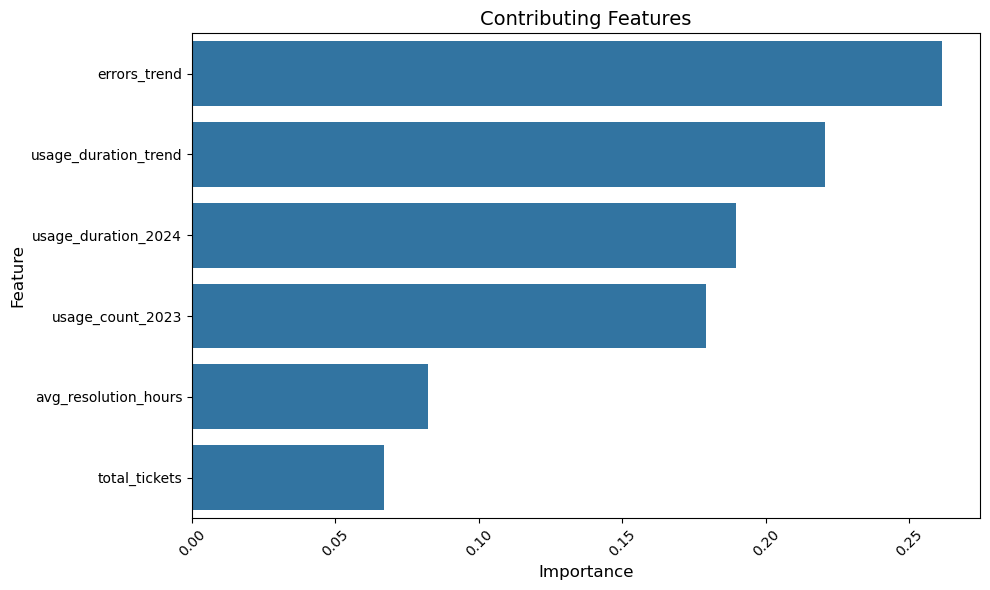

In [185]:
### 9.1 Barplot of feature importance in churn prediction model

# Prepare top features
top_features = importance.head(6)

# Plot
export_barplot(
    df=top_features,
    x='importance',
    y='feature',
    filename='churn_feature_importance.png',
    title='Contributing Features',
    xlabel='Importance',
    ylabel='Feature'
)